In [55]:
import sys

sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction')
sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN')

from tools import *

In [98]:
df_train = pickle.load(open("bdiff/firepoint/2x2/train/occurence_default/df_train_full_departement_0_None_node.pkl", "rb"))
df_test = pickle.load(open("bdiff/firepoint/2x2/train/occurence_default/df_test_full_departement_0_None_node.pkl", "rb"))

cols = ['date', 'departement', 'nbsinister', 'burnedareaRoot', 'saison', 'cluster-encoder', 'mediterranean']

cols_cluster = ['nbsinister-kmeans-5-Class-Dept', 'nbsinister-gm-5-Class-Season']

df_train = df_train[cols + cols_cluster]
df_test = df_test[cols + cols_cluster]
df_train['date'] = df_train['date'].apply(lambda x : allDates[x])
df_test['date'] = df_test['date'].apply(lambda x : allDates[x])

In [57]:
df_train

,date,departement,nbsinister,burnedareaRoot,nbsinister-kmeans-5-Class-Dept,nbsinister-gm-5-Class-Season
0,2017-06-12,18,0.0,0.0,0,0
1,2017-06-12,65,0.0,0.0,0,0
2,2017-06-12,6,1.0,0.0,1,1
3,2017-06-12,52,0.0,0.0,0,0
4,2017-06-12,16,0.0,0.0,0,0
...,...,...,...,...,...,...
152623,2022-12-30,53,0.0,0.0,0,0
152624,2022-12-30,45,0.0,0.0,0,0
152625,2022-12-30,41,0.0,0.0,0,0
152626,2022-12-30,42,0.0,0.0,0,0


<Axes: >

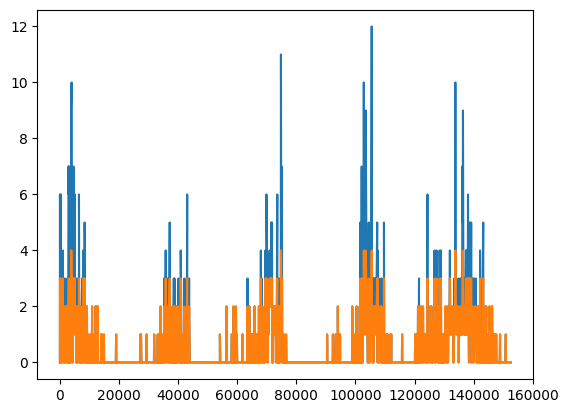

In [58]:
df_train[df_train['departement'] == 13]['nbsinister'].plot()
df_train[df_train['departement'] == 13]['nbsinister-kmeans-5-Class-Dept'].plot()

<Axes: >

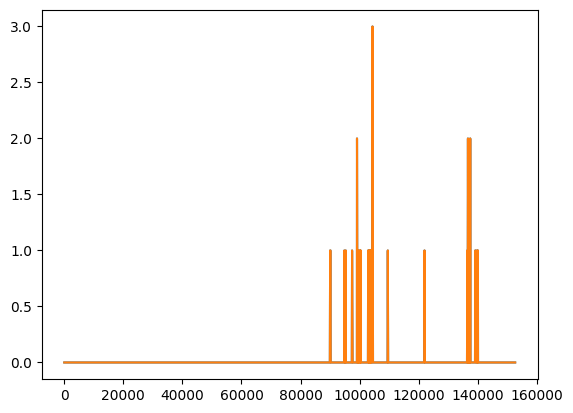

In [59]:
df_train[df_train['departement'] == 85]['nbsinister'].plot()
df_train[df_train['departement'] == 85]['nbsinister-kmeans-5-Class-Dept'].plot()

In [60]:
import numpy as np
import pandas as pd

def add_quantile_classes_per_dept(
    df_train,
    value_col="nbsinister",
    dept_col="departement",
    out_col="nbsinister-quantile-5-Class-Dept",
    quantiles=(0.50, 0.80, 0.95),
):
    df = df_train.copy()
    df[out_col] = 0

    def assign_group(g):
        y = g[value_col].to_numpy()
        mask = y > 0
        if not mask.any():
            return pd.Series(np.zeros(len(g), dtype=np.int8), index=g.index)

        y_pos = y[mask].astype(float)
        qs = np.unique(np.quantile(y_pos, quantiles))

        if len(qs) == 0:
            classes_pos = np.full(y_pos.shape, 4, dtype=np.int8)
        else:
            bins = np.concatenate(([0.0], qs, [np.inf]))
            n_bins = len(bins) - 1
            if n_bins == 1:
                map_classes = [4]
            elif n_bins == 2:
                map_classes = [2, 4]
            elif n_bins == 3:
                map_classes = [1, 3, 4]
            else:
                map_classes = [1, 2, 3, 4] + [4] * max(0, n_bins - 4)

            bin_ids = pd.cut(
                y_pos,
                bins=bins,
                right=True,
                include_lowest=False,
                labels=False,
            )
            classes_pos = np.array([map_classes[int(i)] for i in bin_ids], dtype=np.int8)

        classes = np.zeros(len(g), dtype=np.int8)
        classes[mask] = classes_pos
        return pd.Series(classes, index=g.index)

    df[out_col] = df.groupby(dept_col, group_keys=False).apply(assign_group)
    return df


import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def fit_kmeans_per_dept(
    df_train: pd.DataFrame,
    value_col: str = "nbsinister",
    dept_col: str = "departement",
    n_clusters_pos: int = 4,
    random_state: int = 42,
    n_init: int = 50,
):
    kmeans_by_dept = {}

    for dept, g in df_train.groupby(dept_col):
        y_pos = g.loc[g[value_col] > 0, value_col].to_numpy(dtype=float)
        if y_pos.size == 0:
            continue

        X = y_pos.reshape(-1, 1)
        km = KMeans(
            n_clusters=n_clusters_pos,
            init="k-means++",
            n_init=n_init,
            random_state=random_state,
        ).fit(X)

        centers = km.cluster_centers_.ravel()
        order = np.argsort(centers)
        kmeans_by_dept[dept] = {"model": km, "center_order": order}

    return kmeans_by_dept

In [61]:
df_train = add_quantile_classes_per_dept(df_train)

/tmp/ipykernel_327683/743106531.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[out_col] = df.groupby(dept_col, group_keys=False).apply(assign_group)


In [62]:
cols_cluster = cols_cluster + ['nbsinister-quantile-5-Class-Dept']

In [ ]:
average = {}

for cluster in cols_cluster:
    average[cluster] = {}
    for c in [0, 1, 2, 3, 4]:
        average[cluster][c] = df_train[df_train[cluster] == c]['nbsinister'].mean()

average

{'nbsinister-kmeans-5-Class-Dept': {0: 0.0,
  1: 1.0014903129657229,
  2: 2.0694548170276326,
  3: 3.5708333333333333,
  4: 6.360824742268041},
 'nbsinister-gm-5-Class-Season': {0: 0.0,
  1: 1.0,
  2: 2.0,
  3: 3.2670454545454546,
  4: 6.323741007194244},
 'nbsinister-quantile-5-Class-Dept': {0: 0.0,
  1: 1.0021201413427563,
  2: 1.7836213373403456,
  3: 2.6459537572254335,
  4: 4.680147058823529}}

In [64]:
df_train[(df_train['nbsinister-kmeans-5-Class-Dept'] == 2) & df_train['nbsinister'] == 1].departement.unique()

array([66, 38, 40, 13, 34, 30, 46, 16, 83,  6, 72,  4, 11,  7, 47, 26,  1,
       84, 12,  5, 86, 48, 17, 77, 33, 15, 81, 24, 64, 41, 87, 88, 63, 65,
       39, 32, 74, 36, 23, 35, 58, 52, 21, 76, 37, 45, 71, 31, 70, 19, 67,
       29, 85,  2, 61, 27, 14, 10, 89, 79, 43, 82,  8, 18, 53, 49, 56, 90,
       57, 68, 50, 28, 60, 44, 80])

In [84]:
df_train[df_train['nbsinister-quantile-5-Class-Dept'] == 4].shape

(272, 7)

In [85]:
df_train[df_train['nbsinister-kmeans-5-Class-Dept'] == 4].shape

(97, 7)

<Axes: >

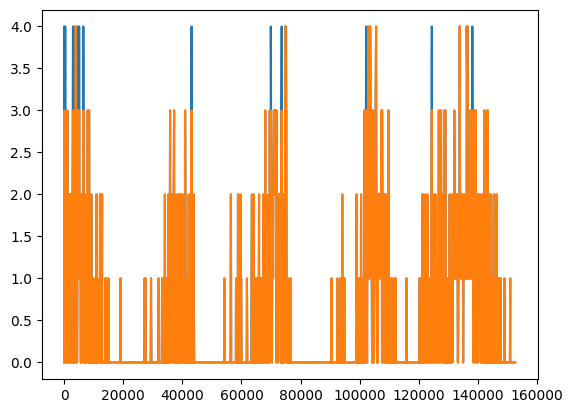

In [65]:
#df_train[df_train['departement'] == 13]['nbsinister-kmeans-5-Class-Dept'].plot()
df_train[df_train['departement'] == 13]['nbsinister-quantile-5-Class-Dept'].plot()
df_train[df_train['departement'] == 13]['nbsinister-kmeans-5-Class-Dept'].plot()

In [66]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


# 1. FIT KMEANS PAR DEPARTEMENT (train uniquement)
def fit_kmeans_per_dept(df_train, value_col, dept_col, n_clusters=4, n_init=50, random_state=0):
    models = {}
    for d, g in df_train.groupby(dept_col):
        y = g.loc[g[value_col] > 0, value_col].values.reshape(-1, 1)
        if len(y) < n_clusters:
            continue
        km = KMeans(n_clusters=n_clusters, n_init=n_init, random_state=random_state).fit(y)
        centers = np.sort(km.cluster_centers_.ravel())
        models[d] = centers
    return models


# 2. ASSIGNATION KMEANS (0 = pas de feu)
def assign_kmeans_classes(df, kmeans_centers, value_col, dept_col, out_col):
    df = df.copy()
    df[out_col] = 0
    for d, centers in kmeans_centers.items():
        idx = (df[dept_col] == d) & (df[value_col] > 0)
        if not idx.any():
            continue
        bins = np.concatenate(([0], (centers[:-1] + centers[1:]) / 2, [np.inf]))
        df.loc[idx, out_col] = np.digitize(df.loc[idx, value_col], bins)
    return df


# 3. ASSIGNATION QUANTILES (0 = pas de feu)
def assign_quantile_classes(df_train, df, value_col, dept_col, out_col, quantiles=(0.5, 0.8, 0.95)):
    df = df.copy()
    df[out_col] = 0
    for d, g in df_train.groupby(dept_col):
        y_pos = g.loc[g[value_col] > 0, value_col].values
        if len(y_pos) == 0:
            continue
        qs = np.quantile(y_pos, quantiles)
        bins = np.concatenate(([0], qs, [np.inf]))
        idx = (df[dept_col] == d) & (df[value_col] > 0)
        df.loc[idx, out_col] = np.digitize(df.loc[idx, value_col], bins)
    return df


# 4. STABILITE BOOTSTRAP (VARIANCE DES SEUILS)
def bootstrap_threshold_variance(df_train, value_col, dept_col, method="quantile", B=100):
    out = {}
    for d, g in df_train.groupby(dept_col):
        y = g.loc[g[value_col] > 0, value_col].values
        if len(y) < 10:
            continue
        thresholds = []
        for _ in range(B):
            ys = np.random.choice(y, size=len(y), replace=True)
            if method == "quantile":
                t = np.quantile(ys, [0.5, 0.8, 0.95])
            else:
                km = KMeans(n_clusters=4, n_init=10).fit(ys.reshape(-1, 1))
                c = np.sort(km.cluster_centers_.ravel())
                t = (c[:-1] + c[1:]) / 2
            thresholds.append(t)
        thresholds = np.vstack(thresholds)
        out[d] = thresholds.std(axis=0)
    return out


# 5. SENSIBILITE AUX OUTLIERS
def outlier_sensitivity(y, method="quantile", factor=5.0):
    y_ext = np.append(y, y.max() * factor)
    if method == "quantile":
        t0 = np.quantile(y, [0.5, 0.8, 0.95])
        t1 = np.quantile(y_ext, [0.5, 0.8, 0.95])
    else:
        km0 = KMeans(n_clusters=4).fit(y.reshape(-1, 1))
        km1 = KMeans(n_clusters=4).fit(y_ext.reshape(-1, 1))
        c0 = np.sort(km0.cluster_centers_.ravel())
        c1 = np.sort(km1.cluster_centers_.ravel())
        t0 = (c0[:-1] + c0[1:]) / 2
        t1 = (c1[:-1] + c1[1:]) / 2
    return np.abs(t1 - t0) / (t0 + 1e-6)


# 6. COHERENCE ORDINALE (violations)
def ordinal_violations(df, value_col, class_col):
    med = df.groupby(class_col)[value_col].median()
    return np.sum(np.diff(med.values) < 0)


# 7. STABILITE TEMPORELLE (train vs test)
def temporal_drift(df_train, df_test, class_col):
    p_train = df_train[class_col].value_counts(normalize=True)
    p_test = df_test[class_col].value_counts(normalize=True)
    return (p_test - p_train).fillna(0)


# 8. ENTROPIE DES CLASSES
def class_entropy(df, class_col):
    p = df[class_col].value_counts(normalize=True)
    return -(p * np.log(p + 1e-9)).sum()


In [86]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score

def test_clustering_schemes(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    value_col: str = "burnedareaRoot",
    dept_col: str = "departement",
    date_col: str = "date",
    quantiles=(0.5, 0.8, 0.95),
    n_clusters_kmeans: int = 4,
    kmeans_n_init: int = 50,
    kmeans_random_state: int = 0,
    bootstrap_B: int = 100,
    outlier_factor: float = 5.0,
):
    kcenters = fit_kmeans_per_dept(
        df_train,
        value_col=value_col,
        dept_col=dept_col,
        n_clusters=n_clusters_kmeans,
        n_init=kmeans_n_init,
        random_state=kmeans_random_state,
    )

    tr_km = assign_kmeans_classes(
        df_train, kcenters, value_col=value_col, dept_col=dept_col, out_col="cls_kmeans"
    )
    te_km = assign_kmeans_classes(
        df_test, kcenters, value_col=value_col, dept_col=dept_col, out_col="cls_kmeans"
    )

    tr_q = assign_quantile_classes(
        df_train,
        df_train,
        value_col=value_col,
        dept_col=dept_col,
        out_col="cls_quantile",
        quantiles=quantiles,
    )
    te_q = assign_quantile_classes(
        df_train,
        df_test,
        value_col=value_col,
        dept_col=dept_col,
        out_col="cls_quantile",
        quantiles=quantiles,
    )

    boot_q = bootstrap_threshold_variance(
        df_train, value_col=value_col, dept_col=dept_col, method="quantile", B=bootstrap_B
    )
    boot_k = bootstrap_threshold_variance(
        df_train, value_col=value_col, dept_col=dept_col, method="kmeans", B=bootstrap_B
    )

    rows = []
    for d, gtr in df_train.groupby(dept_col):
        y_pos = gtr.loc[gtr[value_col] > 0, value_col].to_numpy(dtype=float)
        if y_pos.size < 3:
            continue

        sens_q = outlier_sensitivity(y_pos, method="quantile", factor=outlier_factor)
        sens_k = outlier_sensitivity(y_pos, method="kmeans", factor=outlier_factor)

        tr_sub_km = tr_km.loc[tr_km[dept_col] == d]
        te_sub_km = te_km.loc[te_km[dept_col] == d]
        tr_sub_q = tr_q.loc[tr_q[dept_col] == d]
        te_sub_q = te_q.loc[te_q[dept_col] == d]

        ov_km_train = ordinal_violations(tr_sub_km, value_col=value_col, class_col="cls_kmeans")
        ov_q_train = ordinal_violations(tr_sub_q, value_col=value_col, class_col="cls_quantile")
        ov_km_test = ordinal_violations(te_sub_km, value_col=value_col, class_col="cls_kmeans")
        ov_q_test = ordinal_violations(te_sub_q, value_col=value_col, class_col="cls_quantile")

        ent_km_train = class_entropy(tr_sub_km, class_col="cls_kmeans")
        ent_q_train = class_entropy(tr_sub_q, class_col="cls_quantile")
        ent_km_test = class_entropy(te_sub_km, class_col="cls_kmeans")
        ent_q_test = class_entropy(te_sub_q, class_col="cls_quantile")

        drift_km = temporal_drift(tr_sub_km, te_sub_km, class_col="cls_kmeans")
        drift_q = temporal_drift(tr_sub_q, te_sub_q, class_col="cls_quantile")
        drift_km_l1 = float(np.abs(drift_km).sum())
        drift_q_l1 = float(np.abs(drift_q).sum())
        drift_km_c4 = float(drift_km.get(4, 0.0))
        drift_q_c4 = float(drift_q.get(4, 0.0))

        idx_pos = (tr_sub_km[value_col] > 0) & (tr_sub_q[value_col] > 0)
        if idx_pos.any():
            ari = adjusted_rand_score(
                tr_sub_km.loc[idx_pos, "cls_kmeans"].to_numpy(),
                tr_sub_q.loc[idx_pos, "cls_quantile"].to_numpy(),
            )
        else:
            ari = np.nan

        rows.append(
            {
                dept_col: d,
                "bootstrap_std_quantile_t1": float(boot_q.get(d, [np.nan, np.nan, np.nan])[0]),
                "bootstrap_std_quantile_t2": float(boot_q.get(d, [np.nan, np.nan, np.nan])[1]),
                "bootstrap_std_quantile_t3": float(boot_q.get(d, [np.nan, np.nan, np.nan])[2]),
                "bootstrap_std_kmeans_t1": float(boot_k.get(d, [np.nan, np.nan, np.nan])[0]),
                "bootstrap_std_kmeans_t2": float(boot_k.get(d, [np.nan, np.nan, np.nan])[1]),
                "bootstrap_std_kmeans_t3": float(boot_k.get(d, [np.nan, np.nan, np.nan])[2]),
                "outlier_sens_quantile_t1": float(sens_q[0]),
                "outlier_sens_quantile_t2": float(sens_q[1]),
                "outlier_sens_quantile_t3": float(sens_q[2]),
                "outlier_sens_kmeans_t1": float(sens_k[0]),
                "outlier_sens_kmeans_t2": float(sens_k[1]),
                "outlier_sens_kmeans_t3": float(sens_k[2]),
                "ordinal_violations_train_kmeans": int(ov_km_train),
                "ordinal_violations_train_quantile": int(ov_q_train),
                "ordinal_violations_test_kmeans": int(ov_km_test),
                "ordinal_violations_test_quantile": int(ov_q_test),
                "entropy_train_kmeans": float(ent_km_train),
                "entropy_train_quantile": float(ent_q_train),
                "entropy_test_kmeans": float(ent_km_test),
                "entropy_test_quantile": float(ent_q_test),
                "drift_l1_kmeans": drift_km_l1,
                "drift_l1_quantile": drift_q_l1,
                "drift_class4_kmeans": drift_km_c4,
                "drift_class4_quantile": drift_q_c4,
                "ari_train_pos_kmeans_vs_quantile": float(ari) if ari == ari else np.nan,
            }
        )

    results_by_dept = pd.DataFrame(rows).sort_values(dept_col).reset_index(drop=True)

    def _global_summary(df_res: pd.DataFrame) -> pd.Series:
        cols = df_res.columns.drop(dept_col)
        return df_res[cols].agg(["mean", "median"])

    summary = _global_summary(results_by_dept)

    return {
        "train_labeled": {"kmeans": tr_km, "quantile": tr_q},
        "test_labeled": {"kmeans": te_km, "quantile": te_q},
        "by_dept_metrics": results_by_dept,
        "summary": summary,
    }
    
import numpy as np
import pandas as pd

def compare_schemes(report, dept_col="departement", prefer_low=True):
    df = report["by_dept_metrics"].copy()

    def _wins(col_k, col_q):
        a = df[col_k].to_numpy(dtype=float)
        b = df[col_q].to_numpy(dtype=float)
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() == 0:
            return {"kmeans_better": 0, "quantile_better": 0, "tie": 0, "n": 0}
        a, b = a[m], b[m]
        if prefer_low:
            k_better = int((a < b).sum())
            q_better = int((b < a).sum())
        else:
            k_better = int((a > b).sum())
            q_better = int((b > a).sum())
        tie = int((a == b).sum())
        return {"kmeans_better": k_better, "quantile_better": q_better, "tie": tie, "n": int(m.sum())}

    def _add_delta(cols_k, cols_q, out_col):
        dk = df[cols_k].mean(axis=1)
        dq = df[cols_q].mean(axis=1)
        df[out_col] = dk - dq
        return df

    df = _add_delta(
        ["bootstrap_std_kmeans_t1", "bootstrap_std_kmeans_t2", "bootstrap_std_kmeans_t3"],
        ["bootstrap_std_quantile_t1", "bootstrap_std_quantile_t2", "bootstrap_std_quantile_t3"],
        "delta_bootstrap_std_kmeans_minus_quantile",
    )
    df = _add_delta(
        ["outlier_sens_kmeans_t1", "outlier_sens_kmeans_t2", "outlier_sens_kmeans_t3"],
        ["outlier_sens_quantile_t1", "outlier_sens_quantile_t2", "outlier_sens_quantile_t3"],
        "delta_outlier_sens_kmeans_minus_quantile",
    )

    summary = {}

    summary["bootstrap_std"] = _wins(
        "bootstrap_std_kmeans_t3",
        "bootstrap_std_quantile_t3",
    )
    summary["outlier_sensitivity"] = _wins(
        "outlier_sens_kmeans_t3",
        "outlier_sens_quantile_t3",
    )
    summary["drift_class4"] = _wins(
        "drift_class4_kmeans",
        "drift_class4_quantile",
    )
    summary["drift_l1"] = _wins(
        "drift_l1_kmeans",
        "drift_l1_quantile",
    )
    summary["ordinal_violations_train"] = _wins(
        "ordinal_violations_train_kmeans",
        "ordinal_violations_train_quantile",
    )
    summary["ordinal_violations_test"] = _wins(
        "ordinal_violations_test_kmeans",
        "ordinal_violations_test_quantile",
    )

    def _aggregate_score(row):
        vals = [
            row["delta_bootstrap_std_kmeans_minus_quantile"],
            row["delta_outlier_sens_kmeans_minus_quantile"],
            row["drift_l1_kmeans"] - row["drift_l1_quantile"],
            row["ordinal_violations_test_kmeans"] - row["ordinal_violations_test_quantile"],
        ]
        vals = [v for v in vals if np.isfinite(v)]
        return float(np.mean(vals)) if vals else np.nan

    df["aggregate_score_kmeans_minus_quantile"] = df.apply(_aggregate_score, axis=1)

    overall = {
        "kmeans_better_departments": int((df["aggregate_score_kmeans_minus_quantile"] < 0).sum()),
        "quantile_better_departments": int((df["aggregate_score_kmeans_minus_quantile"] > 0).sum()),
        "tie_or_nan_departments": int(df["aggregate_score_kmeans_minus_quantile"].isna().sum()
                                      + (df["aggregate_score_kmeans_minus_quantile"] == 0).sum()),
        "median_score_kmeans_minus_quantile": float(df["aggregate_score_kmeans_minus_quantile"].median(skipna=True)),
        "mean_score_kmeans_minus_quantile": float(df["aggregate_score_kmeans_minus_quantile"].mean(skipna=True)),
    }

    top_quantile = df.sort_values("aggregate_score_kmeans_minus_quantile", ascending=False).head(10)[
        [dept_col, "aggregate_score_kmeans_minus_quantile",
         "delta_bootstrap_std_kmeans_minus_quantile",
         "delta_outlier_sens_kmeans_minus_quantile",
         "drift_l1_kmeans", "drift_l1_quantile",
         "ordinal_violations_test_kmeans", "ordinal_violations_test_quantile"]
    ].reset_index(drop=True)

    top_kmeans = df.sort_values("aggregate_score_kmeans_minus_quantile", ascending=True).head(10)[
        [dept_col, "aggregate_score_kmeans_minus_quantile",
         "delta_bootstrap_std_kmeans_minus_quantile",
         "delta_outlier_sens_kmeans_minus_quantile",
         "drift_l1_kmeans", "drift_l1_quantile",
         "ordinal_violations_test_kmeans", "ordinal_violations_test_quantile"]
    ].reset_index(drop=True)

    return {
        "by_dept_with_deltas": df,
        "key_metric_wins": summary,
        "overall": overall,
        "top_departments_quantile_better": top_quantile,
        "top_departments_kmeans_better": top_kmeans,
    }


In [87]:
summary = test_clustering_schemes(df_train, df_test)

In [90]:
compare = compare_schemes(summary)

In [91]:
compare['key_metric_wins']

{'bootstrap_std': {'kmeans_better': 41,
  'quantile_better': 35,
  'tie': 0,
  'n': 76},
 'outlier_sensitivity': {'kmeans_better': 3,
  'quantile_better': 80,
  'tie': 0,
  'n': 83},
 'drift_class4': {'kmeans_better': 6,
  'quantile_better': 20,
  'tie': 57,
  'n': 83},
 'drift_l1': {'kmeans_better': 32, 'quantile_better': 34, 'tie': 17, 'n': 83},
 'ordinal_violations_train': {'kmeans_better': 0,
  'quantile_better': 0,
  'tie': 83,
  'n': 83},
 'ordinal_violations_test': {'kmeans_better': 0,
  'quantile_better': 0,
  'tie': 83,
  'n': 83}}

In [92]:
compare['overall']

{'kmeans_better_departments': 40,
 'quantile_better_departments': 43,
 'tie_or_nan_departments': 0,
 'median_score_kmeans_minus_quantile': 0.14319617196807996,
 'mean_score_kmeans_minus_quantile': 15.630846181366508}

In [101]:
import numpy as np
import pandas as pd

# ---------- Quantile-only utils (fit on train, apply to train/test) ----------

def fit_quantile_thresholds_per_group(
    df_train: pd.DataFrame,
    value_col: str,
    group_col: str,
    quantiles=(0.5, 0.8, 0.95),
):
    thr = {}
    for gname, g in df_train.groupby(group_col):
        y_pos = g.loc[g[value_col] > 0, value_col].to_numpy(dtype=float)
        if y_pos.size == 0:
            continue
        thr[gname] = np.quantile(y_pos, quantiles)
    return thr


def assign_quantile_classes_by_group(
    df: pd.DataFrame,
    thresholds_by_group: dict,
    value_col: str,
    group_col: str,
    out_col: str,
):
    d = df.copy()
    d[out_col] = 0
    for gname, qs in thresholds_by_group.items():
        idx = (d[group_col] == gname) & (d[value_col] > 0)
        if not idx.any():
            continue
        bins = np.concatenate(([0.0], np.asarray(qs, dtype=float), [np.inf]))
        d.loc[idx, out_col] = np.digitize(d.loc[idx, value_col].to_numpy(), bins, right=True)
    return d


def bootstrap_threshold_variance_quantile_by_group(
    df_train: pd.DataFrame,
    value_col: str,
    group_col: str,
    quantiles=(0.5, 0.8, 0.95),
    B: int = 100,
    random_state: int = 0,
    min_pos: int = 10,
):
    rng = np.random.default_rng(random_state)
    out = {}
    for gname, g in df_train.groupby(group_col):
        y = g.loc[g[value_col] > 0, value_col].to_numpy(dtype=float)
        if y.size < min_pos:
            continue
        th = []
        for _ in range(B):
            ys = rng.choice(y, size=y.size, replace=True)
            th.append(np.quantile(ys, quantiles))
        out[gname] = np.vstack(th).std(axis=0)
    return out


def outlier_sensitivity_quantile(y_pos: np.ndarray, quantiles=(0.5, 0.8, 0.95), factor: float = 5.0):
    y_pos = np.asarray(y_pos, dtype=float)
    if y_pos.size == 0:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    y_ext = np.append(y_pos, y_pos.max() * factor)
    t0 = np.quantile(y_pos, quantiles)
    t1 = np.quantile(y_ext, quantiles)
    return np.abs(t1 - t0) / (t0 + 1e-9)


def class_entropy(df: pd.DataFrame, class_col: str):
    if df.empty:
        return np.nan
    p = df[class_col].value_counts(normalize=True)
    return float(-(p * np.log(p + 1e-12)).sum())


def temporal_drift(df_train_labeled: pd.DataFrame, df_test_labeled: pd.DataFrame, class_col: str):
    p_train = df_train_labeled[class_col].value_counts(normalize=True)
    p_test = df_test_labeled[class_col].value_counts(normalize=True)
    return (p_test - p_train).fillna(0.0)


def ordinal_violations(df: pd.DataFrame, value_col: str, class_col: str):
    if df.empty:
        return 0
    med = df.groupby(class_col)[value_col].median()
    if med.shape[0] <= 1:
        return 0
    return int(np.sum(np.diff(med.values) < 0))


# ---------- Main: evaluate quantile scheme for a given grouping column ----------

def evaluate_quantile_grouping(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    value_col: str,
    group_col: str,                      # "departement", "saison", "cluster-encoder", "france"
    quantiles=(0.5, 0.8, 0.95),
    bootstrap_B: int = 100,
    bootstrap_random_state: int = 0,
    outlier_factor: float = 5.0,
    min_pos_for_metrics: int = 3,
):
    tr = df_train.copy()
    te = df_test.copy()

    if group_col == "france":
        tr["france"] = "france"
        te["france"] = "france"
        group_col = "france"
    else:
        if group_col not in tr.columns or group_col not in te.columns:
            raise ValueError(f"'{group_col}' doit exister dans df_train et df_test.")

    thr = fit_quantile_thresholds_per_group(
        tr, value_col=value_col, group_col=group_col, quantiles=quantiles
    )

    tr = assign_quantile_classes_by_group(
        tr, thr, value_col=value_col, group_col=group_col, out_col="cls_quantile"
    )
    te = assign_quantile_classes_by_group(
        te, thr, value_col=value_col, group_col=group_col, out_col="cls_quantile"
    )

    boot = bootstrap_threshold_variance_quantile_by_group(
        tr, value_col=value_col, group_col=group_col,
        quantiles=quantiles, B=bootstrap_B, random_state=bootstrap_random_state
    )

    rows = []
    for gname, gtr in tr.groupby(group_col):
        y_pos = gtr.loc[gtr[value_col] > 0, value_col].to_numpy(dtype=float)
        if y_pos.size < min_pos_for_metrics:
            continue

        sens = outlier_sensitivity_quantile(y_pos, quantiles=quantiles, factor=outlier_factor)

        tr_sub = tr.loc[tr[group_col] == gname]
        te_sub = te.loc[te[group_col] == gname]

        ov_tr = ordinal_violations(tr_sub, value_col=value_col, class_col="cls_quantile")
        ov_te = ordinal_violations(te_sub, value_col=value_col, class_col="cls_quantile")

        ent_tr = class_entropy(tr_sub, class_col="cls_quantile")
        ent_te = class_entropy(te_sub, class_col="cls_quantile")

        drift = temporal_drift(tr_sub, te_sub, class_col="cls_quantile")
        drift_l1 = float(np.abs(drift).sum())
        drift_c4 = float(drift.get(4, 0.0))

        b = boot.get(gname, np.array([np.nan, np.nan, np.nan], dtype=float))

        rows.append({
            group_col: gname,
            "bootstrap_std_t1": float(b[0]),
            "bootstrap_std_t2": float(b[1]),
            "bootstrap_std_t3": float(b[2]),
            "outlier_sens_t1": float(sens[0]),
            "outlier_sens_t2": float(sens[1]),
            "outlier_sens_t3": float(sens[2]),
            "ordinal_violations_train": int(ov_tr),
            "ordinal_violations_test": int(ov_te),
            "entropy_train": float(ent_tr) if ent_tr == ent_tr else np.nan,
            "entropy_test": float(ent_te) if ent_te == ent_te else np.nan,
            "drift_l1": drift_l1,
            "drift_class4": drift_c4,
            "n_pos_train": int((gtr[value_col] > 0).sum()),
        })

    by_group = pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)
    cols = [c for c in by_group.columns if c != group_col]
    summary = by_group[cols].agg(["mean", "median"]) if len(by_group) else pd.DataFrame()

    return {
        "group_col": group_col,
        "train_labeled": tr,
        "test_labeled": te,
        "by_group_metrics": by_group,
        "summary": summary,
    }

# ---------- Compare the 3 groupings (departement vs saison vs cluster-encoder) ----------

def compare_quantile_groupings(reports: dict, prefer_low=True):
    def _score(df):
        if df.empty:
            return np.nan
        cols = ["bootstrap_std_t3", "outlier_sens_t3", "drift_l1", "drift_class4", "ordinal_violations_test"]
        vals = df[cols].to_numpy(dtype=float)
        return np.nanmean(vals)

    def _wins(a, b):
        if np.isnan(a) and np.isnan(b):
            return "tie"
        if np.isnan(a):
            return "b"
        if np.isnan(b):
            return "a"
        if prefer_low:
            if a < b: return "a"
            if b < a: return "b"
            return "tie"
        else:
            if a > b: return "a"
            if b > a: return "b"
            return "tie"

    names = list(reports.keys())
    scores = {k: _score(reports[k]["by_group_metrics"]) for k in names}

    pairwise = {}
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            pairwise[f"{a}_vs_{b}"] = {"winner": _wins(scores[a], scores[b]), "score_a": scores[a], "score_b": scores[b]}

    ranked = sorted(scores.items(), key=lambda kv: (np.inf if np.isnan(kv[1]) else kv[1]))

    return {"scores": scores, "ranked": ranked, "pairwise": pairwise}


# ---------- Example ----------
rep_dept   = evaluate_quantile_grouping(df_train, df_test, value_col="burnedareaRoot", group_col="departement")
rep_season = evaluate_quantile_grouping(df_train, df_test, value_col="burnedareaRoot", group_col="saison")
rep_enc    = evaluate_quantile_grouping(df_train, df_test, value_col="burnedareaRoot", group_col="cluster-encoder")
rep_france    = evaluate_quantile_grouping(df_train, df_test, value_col="burnedareaRoot", group_col="france")
rep_med    = evaluate_quantile_grouping(df_train, df_test, value_col="burnedareaRoot", group_col="mediterranean")
comp = compare_quantile_groupings({"departement": rep_dept, "saison": rep_season, "cluster-encoder": rep_enc, 'france' : rep_france, 'mediterranean' : rep_med})

In [102]:
comp

{'scores': {'departement': 25.77735939110588,
  'saison': 3.82977799215113,
  'cluster-encoder': 5.268803303783242,
  'france': 3.060306992525467,
  'mediterranean': 4.424511800243471},
 'ranked': [('france', 3.060306992525467),
  ('saison', 3.82977799215113),
  ('mediterranean', 4.424511800243471),
  ('cluster-encoder', 5.268803303783242),
  ('departement', 25.77735939110588)],
 'pairwise': {'departement_vs_saison': {'winner': 'b',
   'score_a': 25.77735939110588,
   'score_b': 3.82977799215113},
  'departement_vs_cluster-encoder': {'winner': 'b',
   'score_a': 25.77735939110588,
   'score_b': 5.268803303783242},
  'departement_vs_france': {'winner': 'b',
   'score_a': 25.77735939110588,
   'score_b': 3.060306992525467},
  'departement_vs_mediterranean': {'winner': 'b',
   'score_a': 25.77735939110588,
   'score_b': 4.424511800243471},
  'saison_vs_cluster-encoder': {'winner': 'a',
   'score_a': 3.82977799215113,
   'score_b': 5.268803303783242},
  'saison_vs_france': {'winner': 'b',
